### Import data

Data citation - Barreto, G. & Neto, A. (2005). Vertebral Column [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5K89B.

In [78]:
from scipy.io import arff
import pandas
import matplotlib.pyplot as plot
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, DistanceMetric
import numpy

values, metadata = arff.loadarff("../data/column_2C_weka.arff")
data = pandas.DataFrame(values)
data

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,63.027817,22.552586,39.609117,40.475232,98.672917,-0.254400,b'Abnormal'
1,39.056951,10.060991,25.015378,28.995960,114.405425,4.564259,b'Abnormal'
2,68.832021,22.218482,50.092194,46.613539,105.985135,-3.530317,b'Abnormal'
3,69.297008,24.652878,44.311238,44.644130,101.868495,11.211523,b'Abnormal'
4,49.712859,9.652075,28.317406,40.060784,108.168725,7.918501,b'Abnormal'
...,...,...,...,...,...,...,...
305,47.903565,13.616688,36.000000,34.286877,117.449062,-4.245395,b'Normal'
306,53.936748,20.721496,29.220534,33.215251,114.365845,-0.421010,b'Normal'
307,61.446597,22.694968,46.170347,38.751628,125.670725,-2.707880,b'Normal'
308,45.252792,8.693157,41.583126,36.559635,118.545842,0.214750,b'Normal'


### Create scatter plots

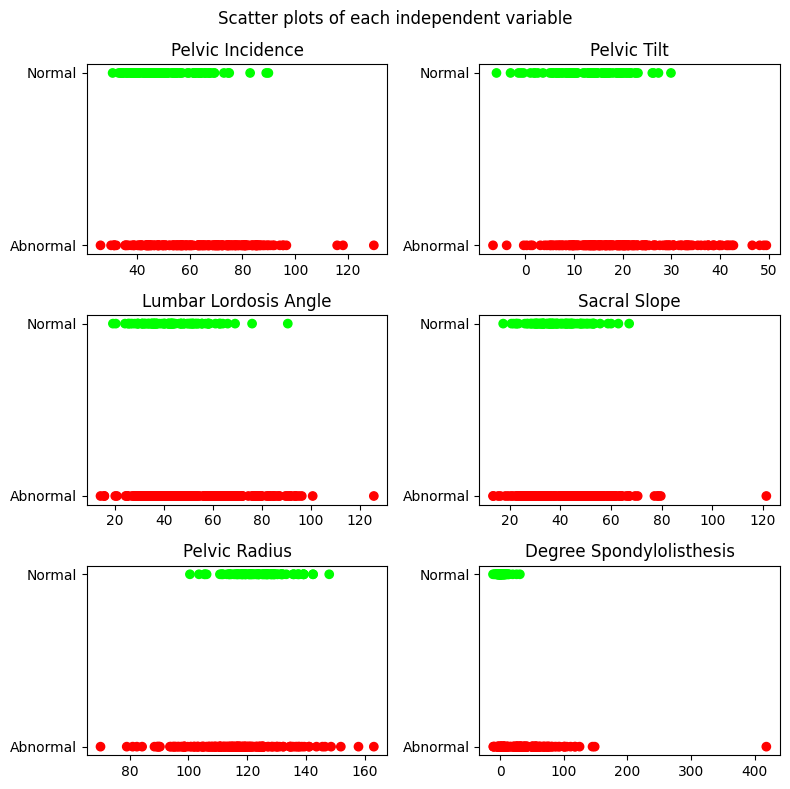

In [79]:

# Define colours
# Abnormal - Red
# Normal - Green

abnormalColor = [1,0,0]
normalColor = [0,1,0]

colors = [normalColor if x==b'Normal' else abnormalColor for x in data['class'] ]

scatterPlots, plots = plot.subplots(3,2,figsize=(8,8))
scatterPlots.suptitle("Scatter plots of each independent variable")

plots[0][0].set_title("Pelvic Incidence")
plots[0][0].scatter(data['pelvic_incidence'], data['class'], c=colors)

plots[0][1].set_title("Pelvic Tilt")
plots[0][1].scatter(data['pelvic_tilt'], data['class'], c=colors)

plots[1][0].set_title("Lumbar Lordosis Angle")
plots[1][0].scatter(data['lumbar_lordosis_angle'], data['class'], c=colors)

plots[1][1].set_title("Sacral Slope")
plots[1][1].scatter(data['sacral_slope'], data['class'], c=colors)

plots[2][0].set_title("Pelvic Radius")
plots[2][0].scatter(data['pelvic_radius'], data['class'], c=colors)

plots[2][1].set_title("Degree Spondylolisthesis")
plots[2][1].scatter(data['degree_spondylolisthesis'], data['class'], c=colors)

scatterPlots.tight_layout()
scatterPlots.show()

### Create box plots

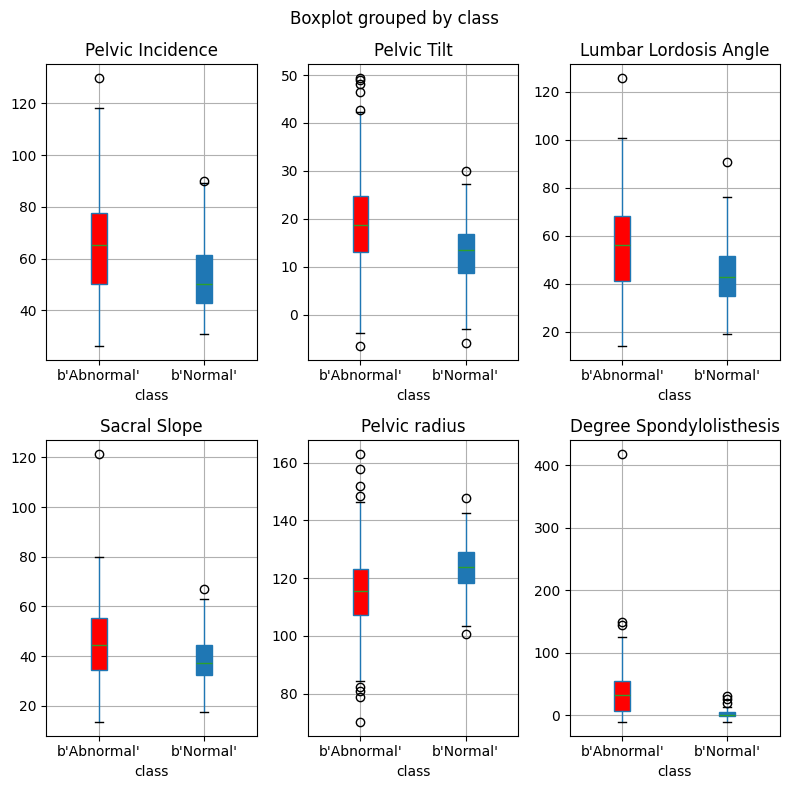

In [80]:
box_plots, axes = plot.subplots(2,3, figsize=(8,8))
box_plots.suptitle("Box plots of each independent variable")

figures = []

figures.append(data.boxplot(column='pelvic_incidence', by='class', ax=axes[0][0], patch_artist=True, return_type='dict'))
axes[0][0].set_title("Pelvic Incidence")

figures.append(data.boxplot(column='pelvic_tilt', by='class', ax=axes[0][1], patch_artist=True, return_type='dict'))
axes[0][1].set_title("Pelvic Tilt")

figures.append(data.boxplot(column='lumbar_lordosis_angle', by='class', ax=axes[0][2], patch_artist=True, return_type='dict'))
axes[0][2].set_title("Lumbar Lordosis Angle")

figures.append(data.boxplot(column='sacral_slope', by='class', ax=axes[1][0], patch_artist=True, return_type='dict'))
axes[1][0].set_title("Sacral Slope")

figures.append(data.boxplot(column='pelvic_radius', by='class', ax=axes[1][1], patch_artist=True, return_type='dict'))
axes[1][1].set_title("Pelvic radius")

figures.append(data.boxplot(column='degree_spondylolisthesis', by='class', ax=axes[1][2], patch_artist=True, return_type='dict'))
axes[1][2].set_title("Degree Spondylolisthesis")

for fig in figures:
    boxes = [x['boxes'] for x in fig]
    for box, i in boxes:
        box.set_facecolor("r")


box_plots.tight_layout()

### Create training and test data

In [81]:
abnormal_data = data[data['class'] == b'Abnormal']
abnormal_data_train = abnormal_data[:140]
abnormal_data_test = abnormal_data[140:]

normal_data = data[data['class'] == b'Normal']
normal_data_train = normal_data[:70]
normal_data_test = normal_data[70:]

training_data = pandas.concat([abnormal_data_train, normal_data_train])
test_data = pandas.concat([abnormal_data_test, normal_data_test])

# Split training data into variables and labels

training_data_variables = training_data.drop(columns='class').reset_index(drop=True)
training_data_labels = training_data['class'].apply(lambda x: 0 if x == b'Normal' else 1).reset_index(drop=True)

test_data_variables = test_data.drop(columns='class').reset_index(drop=True)
test_data_labels = test_data['class'].apply(lambda x: 0 if x == b'Normal' else 1).reset_index(drop=True)

### Perform KNN classification

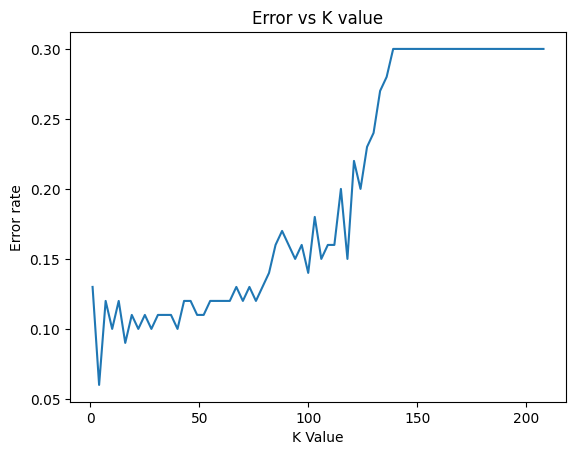

In [82]:
# Create classifiers

classifiers = [dict(classifier = KNeighborsClassifier(n_neighbors=n),
                    neighbours = n,
                    accuracy = 0,
                    predictions=[]) for n in range(1,209,3)]

# Fit classifiers and find accuracy

for classifier in classifiers:
    classifier['classifier'].fit(training_data_variables, training_data_labels)
    classifier['predictions'] = classifier['classifier'].predict(test_data_variables)
    classifier['accuracy'] = accuracy_score(test_data_labels, classifier['predictions'])

accuracies = [(x['neighbours'], x['accuracy']) for x in classifiers]

plot.plot([x[0] for x in accuracies], [1- x[1] for x in accuracies])
plot.xlabel("K Value")
plot.ylabel("Error rate")
plot.title("Error vs K value")
plot.show()

### Best K value and associated errors

In [83]:
bestAccuracy = max([x[1] for x in accuracies])
bestAccuracyIndex = [x[1] for x in accuracies].index(bestAccuracy)
bestK = accuracies[bestAccuracyIndex][0]

print(f'Best value of k by training error={bestK}')
print(f'Best accuracy achieved={bestAccuracy}')
print(f'Confusion matrix for k={bestK}:')
c = confusion_matrix(test_data_labels, classifiers[bestAccuracyIndex]['predictions'])
print(c)
print(f'True negative rate={c[0][0]}, True positive rate={c[1][1]}')
print(f'F1 score for k={bestK} is: {f1_score(test_data_labels, classifiers[bestAccuracyIndex]['predictions'])}')

Best value of k by training error=4
Best accuracy achieved=0.94
Confusion matrix for k=4:
[[25  5]
 [ 1 69]]
True negative rate=25, True positive rate=69
F1 score for k=4 is: 0.9583333333333334


### Best test error rate by training set size

In [84]:
def sample_dataset(dataset, n):
    # Sample n // 3 items from data with class = 0, and n - n // 3 items from data with class = 1
    data0 = dataset[dataset['class'] == b'Normal'][:n//3]
    data1 = dataset[dataset['class'] == b'Abnormal'][:n - n//3]
    data = pandas.concat([data0, data1])
    data.reset_index(drop=True, inplace=True)
    return (data.drop(columns='class'), data['class'].apply(lambda x: 0 if x == b'Normal' else 1))

def find_best_k(sample_dataset, metric='minkowski', p=2, metric_params=None, weights='uniform'):
    n = len(sample_dataset[0])
    classifiers = [dict(classifier = KNeighborsClassifier(n_neighbors=k, metric=metric, p=p, metric_params=metric_params, weights=weights),
                    neighbours = k,
                    accuracy = 0) for k in range(1,n,5)]

    bestAccuracyIndex = 0

    for i, classifier in enumerate(classifiers):
        classifier['classifier'].fit(sample_dataset[0],sample_dataset[1])
        predictions = classifier['classifier'].predict(test_data_variables)
        classifier['accuracy'] = accuracy_score(test_data_labels, predictions)

        if classifier['accuracy'] > classifiers[bestAccuracyIndex]['accuracy']:
            bestAccuracyIndex = i

    return (classifiers[bestAccuracyIndex]['neighbours'], classifiers[bestAccuracyIndex]['accuracy'])


training_samples = [sample_dataset(training_data, i) for i in range(10,220,10)]
best_k_by_sample_size = [find_best_k(sample) for sample in training_samples]

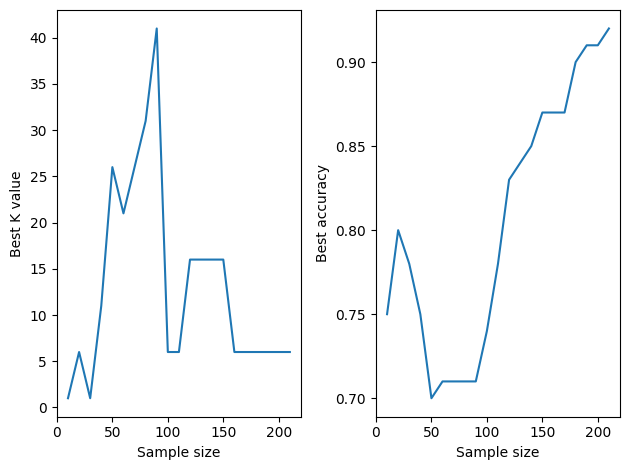

In [85]:
figure, axes = plot.subplots(1,2)

axes[0].plot([len(sample[0]) for sample in training_samples], [x[0] for x in best_k_by_sample_size])
axes[0].set_xlabel("Sample size")
axes[0].set_ylabel("Best K value")

axes[1].plot([len(sample[0]) for sample in training_samples], [x[1] for x in best_k_by_sample_size])
axes[1].set_xlabel("Sample size")
axes[1].set_ylabel("Best accuracy")

figure.tight_layout()
figure.show()

### Exploring other distance functions

In [86]:
def find_accuracy(sample, k, metric='minkowski', p=2):
    classifier = KNeighborsClassifier(n_neighbors=k, metric=metric, p=p)
    classifier.fit(sample[0], sample[1])
    predictions = classifier.predict(test_data_variables)
    return accuracy_score(test_data_labels, predictions)

In [87]:
# Prepare training data
sample = (training_data_variables, training_data_labels)

# Best K for euclidean distance
euclidean_k, euclidean_accuracy = find_best_k(sample)

# Best K for manhattan distance
manhattan_k, manhattan_accuracy = find_best_k(sample, metric='manhattan')

# Best p for log_10{p} in {0.1, 0.2, 0.3, ..., 1}
accuracies = [find_accuracy(sample, 1, p=10**float(i/10)) for i in range(1,11)]
max_accuracy = max(accuracies)
best_log_p = (accuracies.index(max_accuracy) + 1) / 10

# Chebyshev
che_k, che_accuracy = find_best_k(sample, metric='chebyshev')

# Mahalanobis
V = sample[0].cov()
VI = numpy.linalg.inv(V)
mahalanobis_metric = DistanceMetric.get_metric('mahalanobis', V=VI)
mah_k, mah_accuracy = find_best_k(sample, metric=mahalanobis_metric)

results = pandas.DataFrame([[euclidean_k, euclidean_accuracy],[manhattan_k, manhattan_accuracy],[manhattan_k, max_accuracy],[che_k, che_accuracy], [mah_k, mah_accuracy]],
                 index=["Euclidean", "Manhattan", f"Minkowski at log(p)={best_log_p}", "Chebyshev", "Mahalanobis"],
                 columns=["Best k value", "Best accuracy"])

results

,Best k value,Best accuracy
Euclidean,6,0.92
Manhattan,1,0.89
Minkowski at log(p)=0.7,1,0.89
Chebyshev,16,0.92
Mahalanobis,6,0.94


### Using weighted decision

In [88]:
# Euclidean
euclidean_k, euclidean_accuracy = find_best_k(sample, weights='distance')

# Manhattan
manhattan_k, manhattan_accuracy = find_best_k(sample, metric='manhattan', weights='distance')

# Chebyshev
che_k, che_accuracy = find_best_k(sample, metric='chebyshev', weights='distance')

results = pandas.DataFrame([[euclidean_k, euclidean_accuracy],[manhattan_k, manhattan_accuracy],[che_k, che_accuracy]],
                 index=["Euclidean", "Manhattan", "Chebyshev"],
                 columns=["Best k value", "Best accuracy"])

results

,Best k value,Best accuracy
Euclidean,6,0.90
Manhattan,26,0.90
Chebyshev,16,0.89


### Best Accuracy

The best accuracy in this assignment was about 94%, which was achieved with:

Euclidean distance, majority polling, k = 4
Mahalanobis distance, majority polling, k = 6